In [1]:
import collocation_WEB as cWEB
import numpy as np
import matplotlib.pyplot as plt
import importlib
import Geomertry
import mesh
import torch
torch.set_default_dtype(torch.float64)

WEB-Spline Collocation: degree=4, H=100, domain={'x1': -4.0, 'x2': 4.0, 'y1': -3.0, 'y2': 3.0}, case=8
Domain transform: [0,1]² → [-4.0,4.0]×[-3.0,3.0]
Laplacian factors in grid coords: ax=1/scale_x^2=1.562e-02, ay=1/scale_y^2=2.778e-02
Classification...
  Inner B-splines: 7204
  Outer B-splines: 1032
  Inner element arrays: 6172
Building extension matrix...
  Extension matrix: 7204 x 1032, nnz = 10300
Assembling collocation matrix...
Solving linear system...
  System dimension: 7204
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 4.555033e-05
  Relative L2 error:  1.281296e-05
  Mean absolute error: 5.365750e-06
  Absolute L-inf error: 4.555031e-05
  H1 semi-norm error: 1.808435e-01
  H1 error:           1.808435e-01
  Condition number:   N/A
  System dimension:   7204

Timing:
  Classification/Assembly: 0.307s
  Extension:               0.144s
  Solution:                0.300s
  Total:                   0.750s


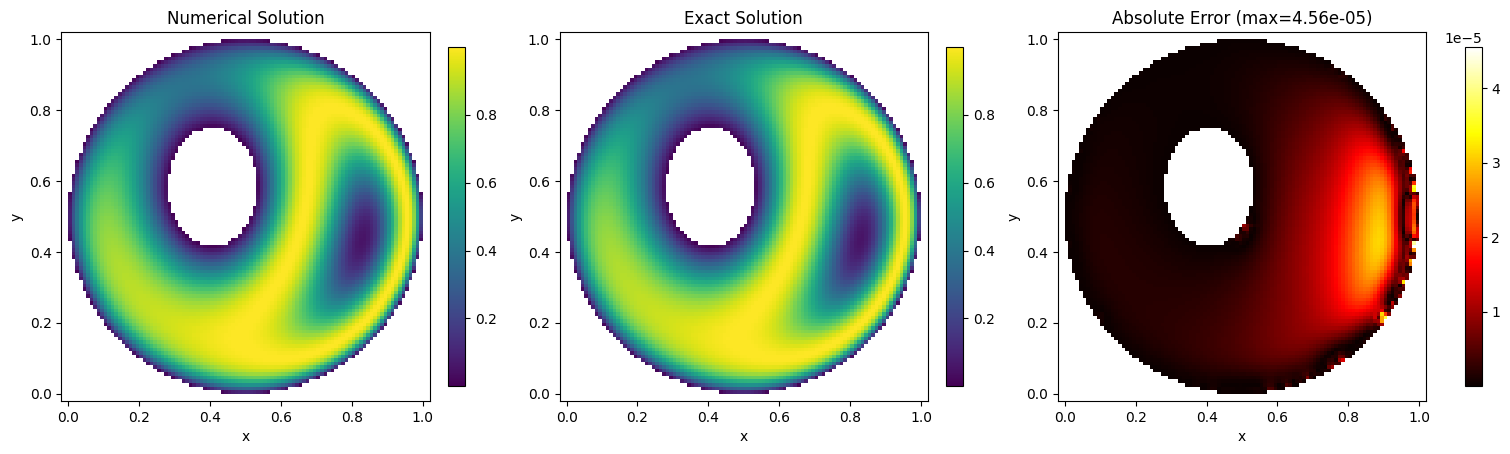

In [33]:
model = Geomertry.AnaliticalDistance_CASE8()
res = cWEB.run_example(model=model, n=4, H=100, function_case=8, verbose=True, plot_mode='2d')

In [24]:
import network_defs as netdefs
import PDE_testcases
import inhomogenous_boundary as ihbnd
importlib.reload(cWEB)
model_MS = netdefs.load_test_model("SIREN_pentagon_MMSDF", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
model = ihbnd.sharp_min_distance_function(model_MS)
n = 2
H = 20
function_case = 11
verbose = True
show_plot = True
CD = None
solve_method  = "auto"
dense_threshold = 2000
plot_mode = "3d"


global DOMAIN

active_case = 11
domain = PDE_testcases.get_domain_for_case(active_case)
DOMAIN = PDE_testcases.DOMAIN


if verbose:
    print("=" * 60)
    print(f"WEB-Spline Collocation: degree={n}, H={H}, domain={DOMAIN}, case={active_case}")
    print("=" * 60)

wfct = cWEB.NeuralWeightFunction(model=model, domain=DOMAIN)
transformer = cWEB.create_domain_transformer(DOMAIN)

if CD is None:
    CD = cWEB.compute_collocation_data(n, J_MAX=16)

Uxy, xB, yB, con, dim_sys, rtimes = cWEB.collocation_2d(
    n,
    H,
    wfct,
    f=PDE_testcases.load_function_vectorized,
    CD=CD,
    verbose=verbose,
    domain=DOMAIN,
    solve_method=solve_method,
    dense_threshold=dense_threshold,
    model=model_MS,
    function_case=active_case
)

if Uxy is None:
    print("Solver failed!")
    raise RuntimeError("Collocation solver failed.")



WEB-Spline Collocation: degree=2, H=20, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 439
  Outer B-splines: 45
  Inner element arrays: 271
Building extension matrix...
  Extension matrix: 439 x 45, nnz = 135
Assembling collocation matrix...
Lifting values: tensor([ 5.1841e-01,  5.1840e-01,  5.1978e-01,  5.2289e-01,  5.2879e-01,
         5.3952e-01,  5.5895e-01,  5.9567e-01,  6.7318e-01,  8.6755e-01,
         1.2253e+00,  1.0679e+00,  7.3053e-01,  6.1073e-01,  5.7695e-01,
         5.7133e-01,  5.7576e-01,  5.8309e-01,  5.8832e-01,  5.8843e-01,
         5.8243e-01,  5.7506e-01,  4.8488e-01,  4.8489e-01,  4.8565e-01,
         4.8751e-01,  4.9133e-01,  4.9868e-01,  5.1267e-01,  5.4020e-01,
         5.9889e-01,  7.5959e-01,  1.3016e+00,  1.3454e+00,  7.6025e-01,
         6.1006e-01,  5.7117e-01,  5.6481e-01,  5.6910e-01,

WEB-Spline Collocation: degree=4, H=200, domain={'x1': -1, 'x2': 1, 'y1': -1, 'y2': 1}, case=11
Domain transform: [0,1]² → [-1,1]×[-1,1]
Laplacian factors in grid coords: ax=1/scale_x^2=2.500e-01, ay=1/scale_y^2=2.500e-01
Classification...
  Inner B-splines: 23785
  Outer B-splines: 1500
  Inner element arrays: 22322
Building extension matrix...
  Extension matrix: 23785 x 1500, nnz = 14280
Assembling collocation matrix...
Lifting values: tensor([0.2039, 0.2038, 0.2036,  ..., 0.0000, 0.0000, 0.0000])
line 1081 -> fiy this later!!! 
Solving linear system...
  System dimension: 23785
  Condition number: N/A (system too large)
Evaluating solution...

Results:
  Relative max error: 1.778506e-01
  Relative L2 error:  1.170293e+01
  Mean absolute error: 5.931926e-02
  Absolute L-inf error: 1.778506e-01
  H1 semi-norm error: N/A
  H1 error:           N/A
  Condition number:   N/A
  System dimension:   23785

Timing:
  Classification/Assembly: 11.884s
  Extension:               0.176s
  Soluti

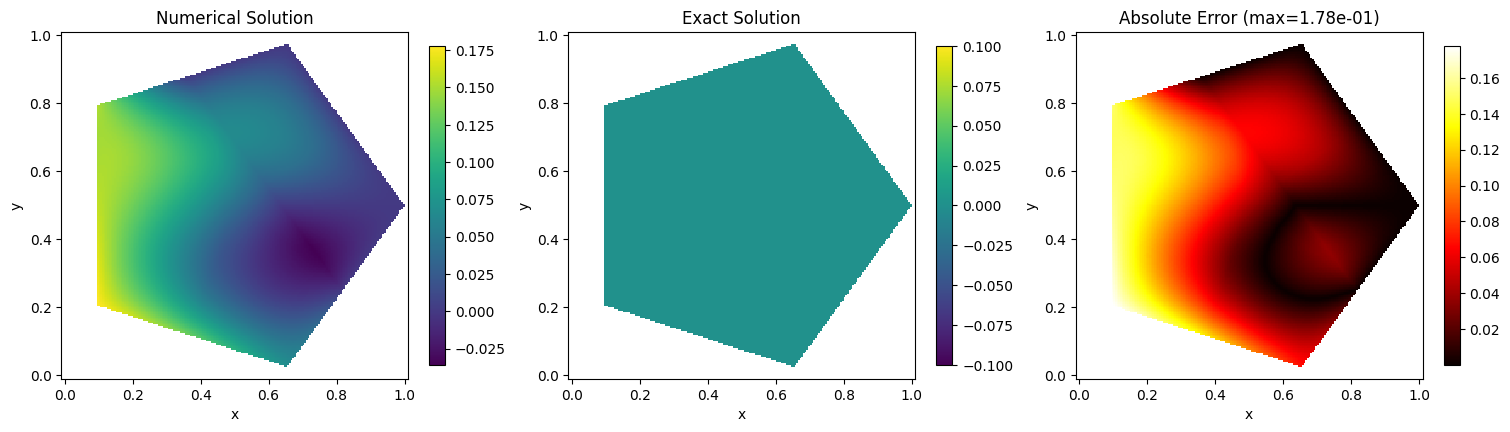

In [48]:
importlib.reload(cWEB)
importlib.reload(PDE_testcases)
import inhomogenous_boundary as ihbnd
importlib.reload(ihbnd)
model_MS = netdefs.load_test_model("SIREN_pentagon_MSSDF_large", "SIREN", params={"architecture": [2, 256, 256, 256, 5], "w_0": 15, "w_hidden": 30.0})
#model = ihbnd.sharp_min_distance_function(model_MS)
#model = ihbnd.smooth_min_distance_function(model_MS, alpha=10.0)
model = ihbnd.smooth_min_preserve_zero_distance_function(model=model_MS, k = 1)
# Enable return_coefficients=True so we can use the result for pointwise evaluation
res = cWEB.run_example(model=model, n=4, H=200, function_case=11, verbose=True, plot_mode='2d', return_coefficients=True, model_ms=model_MS)

Lifting values: tensor([0.2288, 0.0913, 0.2020,  ..., 0.1467, 0.3123, 0.2161])


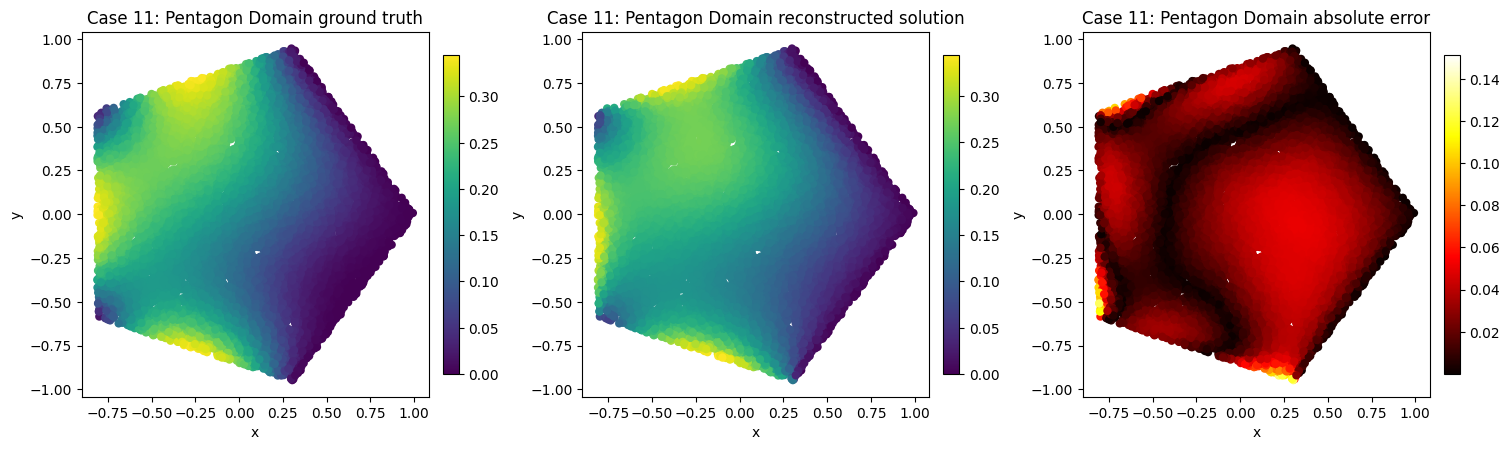


Evaluation at 10000 sample points from poisson_samples.csv
  Ground truth range: [-0.000073, 0.345088]
  Prediction range:   [0.000000, 0.344656]
  Max absolute error: 1.513329e-01
  Mean absolute error: 2.531042e-02


In [50]:
# Plot ground truth, reconstructed solution, and absolute error at CSV sample points
importlib.reload(ihbnd)
importlib.reload(cWEB)
if 'recon_info' in res:
    result = ihbnd.plot_case_11_poisson_samples(
        recon_info=res['recon_info'],
        model=model,
        title_prefix="Case 11: Pentagon Domain",
        show=True,
        filename="poisson_samples_inhom_1_e_3.csv",
        model_ms=model_MS
    )
    print(f"\nEvaluation at {len(result['x'])} sample points from poisson_samples.csv")
    print(f"  Ground truth range: [{result['gt'].min():.6f}, {result['gt'].max():.6f}]")
    print(f"  Prediction range:   [{result['pred'].min():.6f}, {result['pred'].max():.6f}]")
    print(f"  Max absolute error: {np.abs(result['error']).max():.6e}")
    print(f"  Mean absolute error: {np.abs(result['error']).mean():.6e}")
else:
    print("Error: recon_info not found in result. Make sure return_coefficients=True was used.")